# Exploratory Data Analysis

This notebook explores the cleaned dataset produced in `I-cleaning.ipynb`: one row per country-year, combining World Bank development indicators with the Heritage Foundation's Index of Economic Freedom for 185 countries between 2001 and 2025 (`data/processed/wb_economic_freedom_merged.csv`).

The goal is to investigate how economic freedom (property rights, government integrity, trade freedom, and other sub-components) relates to real-world development outcomes (GDP per capita, life expectancy, unemployment, and more), through descriptive statistics, trends over time, and visualisation.

**Parts covered in this notebook:**
1. Imports, loading the cleaned dataset, and initial inspection
2. Global and regional trends over time
3. Relationship between economic freedom and development outcomes
4. Correlation analysis across indicators
5. Key findings and takeaways

<table align="left">
  <tr>
    <td>
      <a href="https://colab.research.google.com/github/ValentimPiazera/wb-economic-freedom/blob/main/notebooks/II-analysis.ipynb" target="_parent">
        <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
      </a>
    </td>
    <td>
      <a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/ValentimPiazera/wb-economic-freedom/blob/main/notebooks/II-analysis.ipynb">
        <img src="https://kaggle.com/static/images/open-in-kaggle.svg" alt="Open In Kaggle"/>
      </a>
    </td>
  </tr>
</table>

> **Note:** this notebook is written to run from the **repository root**, not from `notebooks/`.
> Locally, `.vscode/settings.json` already points VS Code's Jupyter root at the workspace folder;
> from a terminal, launch Jupyter from the repository root.
>
> If you're running on Google Colab or Kaggle, run the cell below first: it clones the repository
> so that the `src/` module and data files are available.
>
> On **Kaggle**, make sure Internet access is enabled: *Settings → Internet → On*.

In [1]:
# Setup: clone repo when running on Colab/Kaggle (skip if running locally!)
import os

IN_COLAB_OR_KAGGLE = (
    "google.colab" in str(get_ipython())
    or "kaggle" in os.environ.get("KAGGLE_URL_BASE", "").lower()
)

if IN_COLAB_OR_KAGGLE:
    if not os.path.exists("wb-economic-freedom"):
        !git clone https://github.com/ValentimPiazera/wb-economic-freedom.git
    # The repo root is the working directory, so `from src import viz`
    # and the `data/` paths below resolve the same way as they do locally.
    %cd wb-economic-freedom
    # Not preinstalled on Colab/Kaggle; used for label placement in Part III.
    !pip install -q adjustText

## Part I | Imports, Loading, and Initial Inspection

Load the cleaned dataset from `data/processed/wb_economic_freedom_merged.csv` and get a first look at its shape, columns, and data types before starting the analysis.

In [2]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import pandas as pd

from src import utils, viz

In [3]:
df = pd.read_csv("data/processed/wb_economic_freedom_merged.csv")

df.head()

,Country Name,Country Code,Year,Carbon dioxide (CO2) emissions (total) excluding LULUCF (Mt CO2e),"Foreign direct investment, net inflows (% of GDP)",GDP (current US$),GDP growth (annual %),"Inflation, consumer prices (annual %)","Life expectancy at birth, total (years)","Population, total",...,Tax Burden,Government Spending,Business Freedom,Labor Freedom,Monetary Freedom,Trade Freedom,Investment Freedom,Financial Freedom,GDP per capita (current US$),Continent
0,Afghanistan,AFG,2001,0.9402,0.024169,2.813572e+09,-9.431974,NaN,55.511,20284307,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,138.706822,Asia
1,Afghanistan,AFG,2002,0.9388,1.306950,3.825701e+09,28.600001,NaN,56.225,21378117,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,178.954088,Asia
2,Afghanistan,AFG,2003,1.0172,1.278493,4.520947e+09,8.832278,NaN,57.171,22733049,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,198.871116,Asia
3,Afghanistan,AFG,2004,0.9024,3.577104,5.224897e+09,1.414118,NaN,57.810,23560654,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,221.763654,Asia
4,Afghanistan,AFG,2005,1.2763,4.368673,6.203257e+09,11.229715,12.686269,58.247,24404567,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,254.184249,Asia


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4581 entries, 0 to 4580
Data columns (total 25 columns):
 #   Column                                                               Non-Null Count  Dtype  
---  ------                                                               --------------  -----  
 0   Country Name                                                         4581 non-null   str    
 1   Country Code                                                         4581 non-null   str    
 2   Year                                                                 4581 non-null   int64  
 3   Carbon dioxide (CO2) emissions (total) excluding LULUCF (Mt CO2e)    4313 non-null   float64
 4   Foreign direct investment, net inflows (% of GDP)                    4256 non-null   float64
 5   GDP (current US$)                                                    4522 non-null   float64
 6   GDP growth (annual %)                                                4498 non-null   float64
 7   Inflation, consum

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,4581.0,2.013028e+03,7.201594e+00,2.001000e+03,2.007000e+03,2.013000e+03,2.019000e+03,2.025000e+03
Carbon dioxide (CO2) emissions (total) excluding LULUCF (Mt CO2e),4313.0,1.820587e+02,8.556816e+02,2.000000e-04,2.984300e+00,1.409680e+01,7.294110e+01,1.312473e+04
"Foreign direct investment, net inflows (% of GDP)",4256.0,7.311693e+00,4.974529e+01,-1.303108e+03,1.190340e+00,2.809549e+00,5.594378e+00,1.282607e+03
GDP (current US$),4522.0,4.037714e+11,1.743695e+12,6.493585e+07,8.034019e+09,3.074509e+10,1.926441e+11,3.076970e+13
GDP growth (annual %),4498.0,3.530866e+00,5.533162e+00,-5.440209e+01,1.501833e+00,3.664719e+00,5.879458e+00,8.682675e+01
"Inflation, consumer prices (annual %)",4263.0,6.459680e+00,1.667305e+01,-1.685969e+01,1.731484e+00,3.604522e+00,7.189209e+00,5.572018e+02
"Life expectancy at birth, total (years)",4396.0,7.047783e+01,8.628947e+00,3.153000e+01,6.493825e+01,7.190087e+01,7.700554e+01,8.549634e+01
"Population, total",4581.0,3.930915e+07,1.424973e+08,3.319400e+04,2.376722e+06,8.720283e+06,2.764936e+07,1.463866e+09
"School enrollment, secondary (% gross)",3177.0,8.274280e+01,2.850791e+01,3.347850e+00,6.709386e+01,8.975031e+01,1.014880e+02,1.640798e+02
"Unemployment, total (% of total labor force) (modeled ILO estimate)",4433.0,7.739484e+00,5.963704e+00,1.000000e-01,3.607000e+00,5.832000e+00,1.020700e+01,3.732000e+01


## Part II | Global Snapshot: Leaders, Laggards, and the Spread

A first orientation pass over a single year: which countries sit at each end of the two headline measures, and how economic freedom scores are distributed across the world.

The reference year is deliberately **not** `df["Year"].max()`. Indicator coverage in this dataset is strongly year-dependent — 2025 is ~95% complete for economic freedom and GDP per capita, but has no life expectancy values at all — so `utils.latest_complete_year()` returns the most recent year that clears a 90% coverage threshold for the specific columns a chart uses. Each snapshot chart then states its own coverage in the subtitle, because a ranking silently omits every country that did not report: in 2025 that quietly removes Liechtenstein, the highest GDP per capita in the dataset, from the top ten.

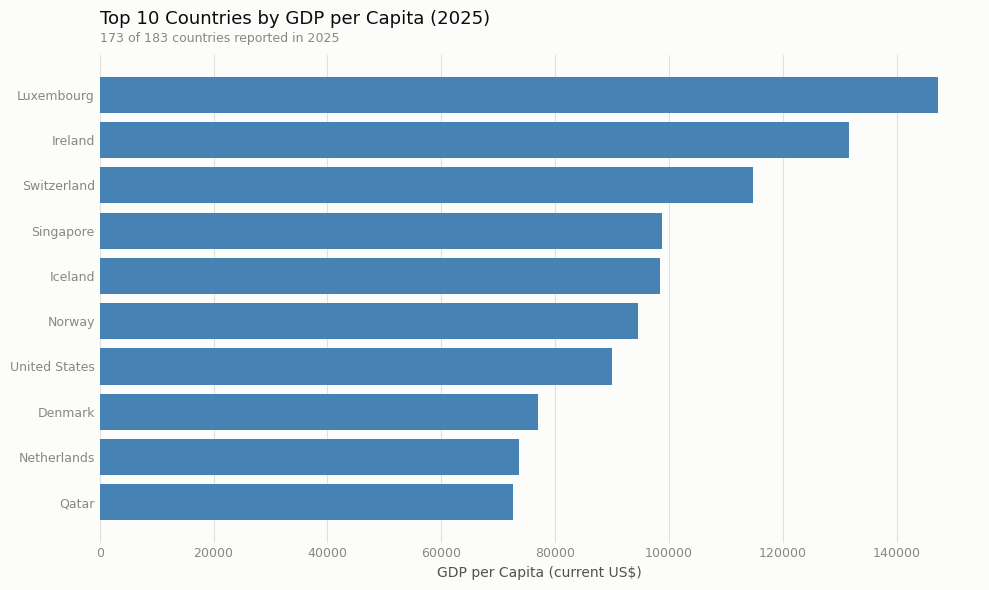

In [6]:
gdp_col = "GDP per capita (current US$)"
freedom_col = "Overall Score"

# Coverage-driven rather than df["Year"].max(); see the note above.
latest_year = utils.latest_complete_year(df, [freedom_col, gdp_col])

fig = viz.plot_top_countries(
    df,
    gdp_col,
    latest_year,
    title=f"Top 10 Countries by GDP per Capita ({latest_year})",
    xlabel="GDP per Capita (current US$)",
    subtitle=utils.coverage_note(df, [gdp_col], latest_year),
    color="steelblue",
)
plt.show()

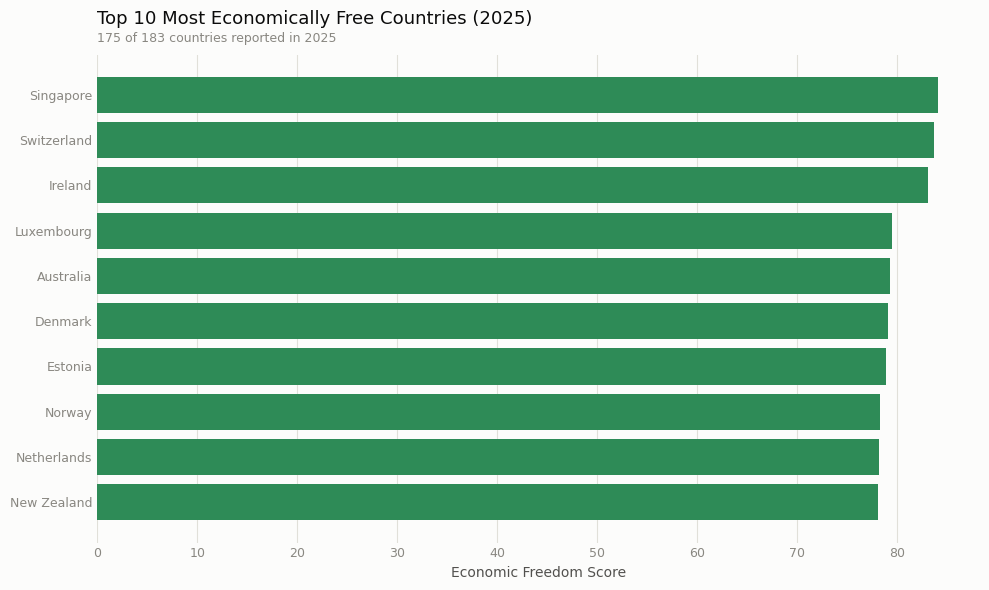

In [7]:
fig = viz.plot_top_countries(
    df,
    freedom_col,
    latest_year,
    title=f"Top 10 Most Economically Free Countries ({latest_year})",
    xlabel="Economic Freedom Score",
    subtitle=utils.coverage_note(df, [freedom_col], latest_year),
    color="seagreen",
)
plt.show()

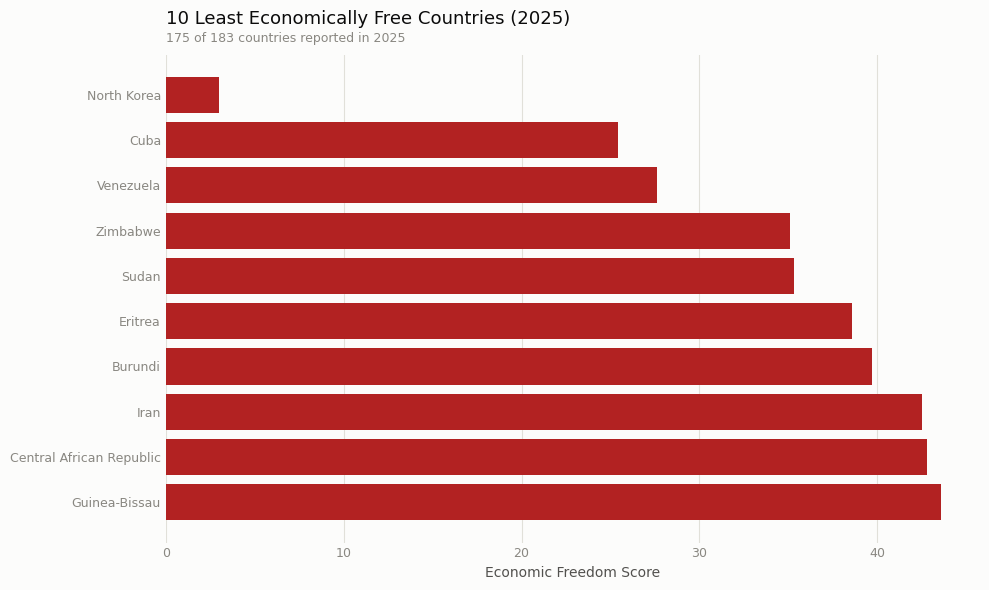

In [8]:
fig = viz.plot_top_countries(
    df,
    freedom_col,
    latest_year,
    title=f"10 Least Economically Free Countries ({latest_year})",
    xlabel="Economic Freedom Score",
    subtitle=utils.coverage_note(df, [freedom_col], latest_year),
    largest=False,
    color="firebrick",
)
plt.show()

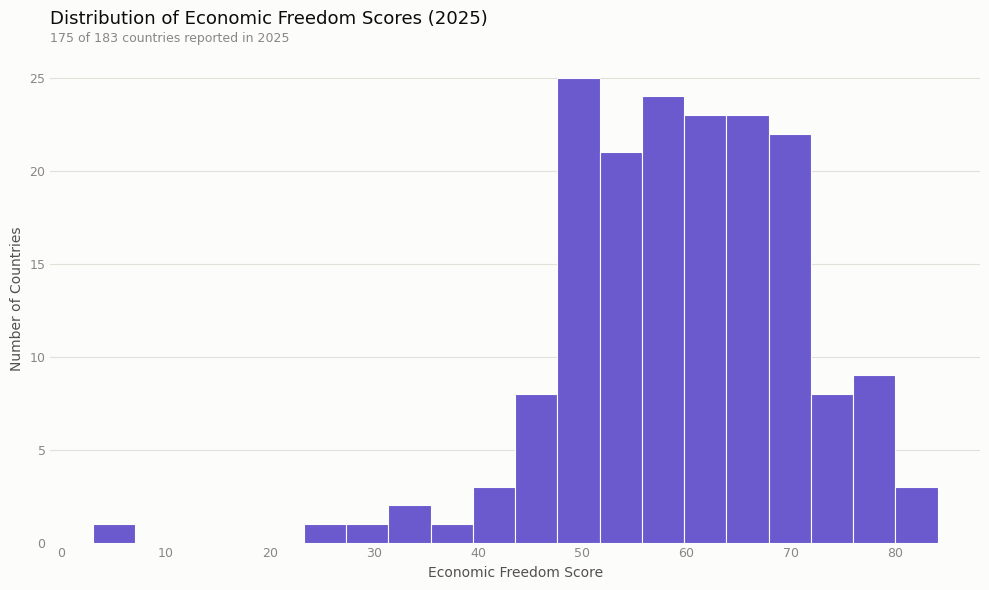

In [9]:
fig = viz.plot_score_distribution(
    df,
    latest_year,
    title=f"Distribution of Economic Freedom Scores ({latest_year})",
    xlabel="Economic Freedom Score",
    subtitle=utils.coverage_note(df, [freedom_col], latest_year),
)
plt.show()

In [10]:
viz.scatter_freedom_development(df).show()

In [11]:
viz.choropleth_freedom(df).show()

## Part III | Relationship Between Economic Freedom and Development Outcomes

Compare countries by economic freedom level against development outcomes such as GDP per capita, life expectancy, and unemployment.

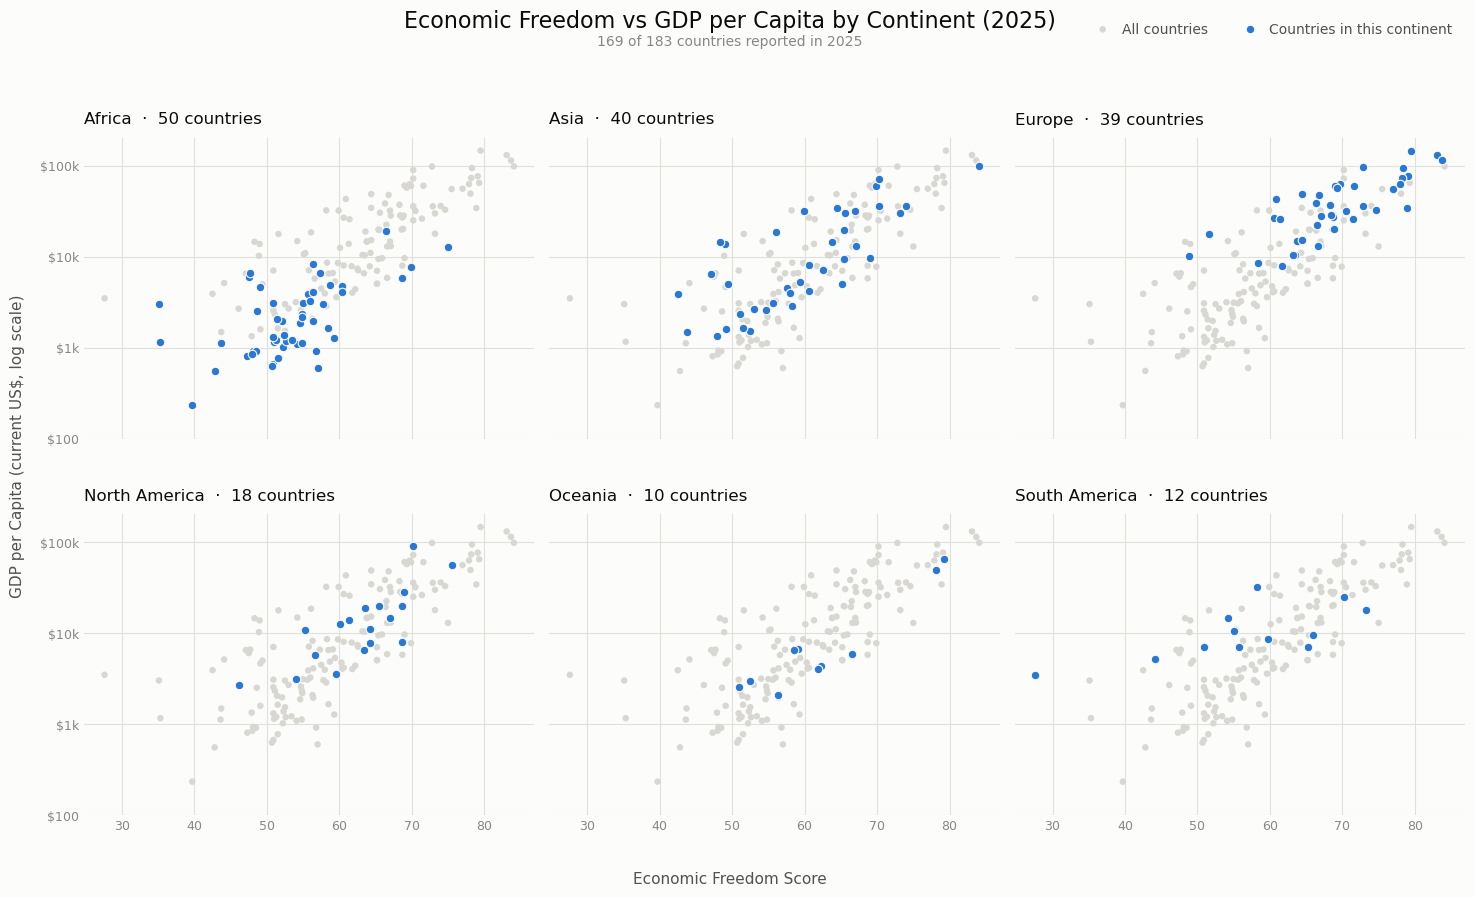

In [12]:
snapshot = df[df["Year"] == latest_year].dropna(
    subset=[freedom_col, gdp_col]
)
continents = sorted(snapshot["Continent"].dropna().unique())

fig = viz.plot_continent_overview(
    snapshot,
    continents,
    latest_year,
    gdp_col,
    subtitle=utils.coverage_note(df, [freedom_col, gdp_col], latest_year),
)
plt.show()

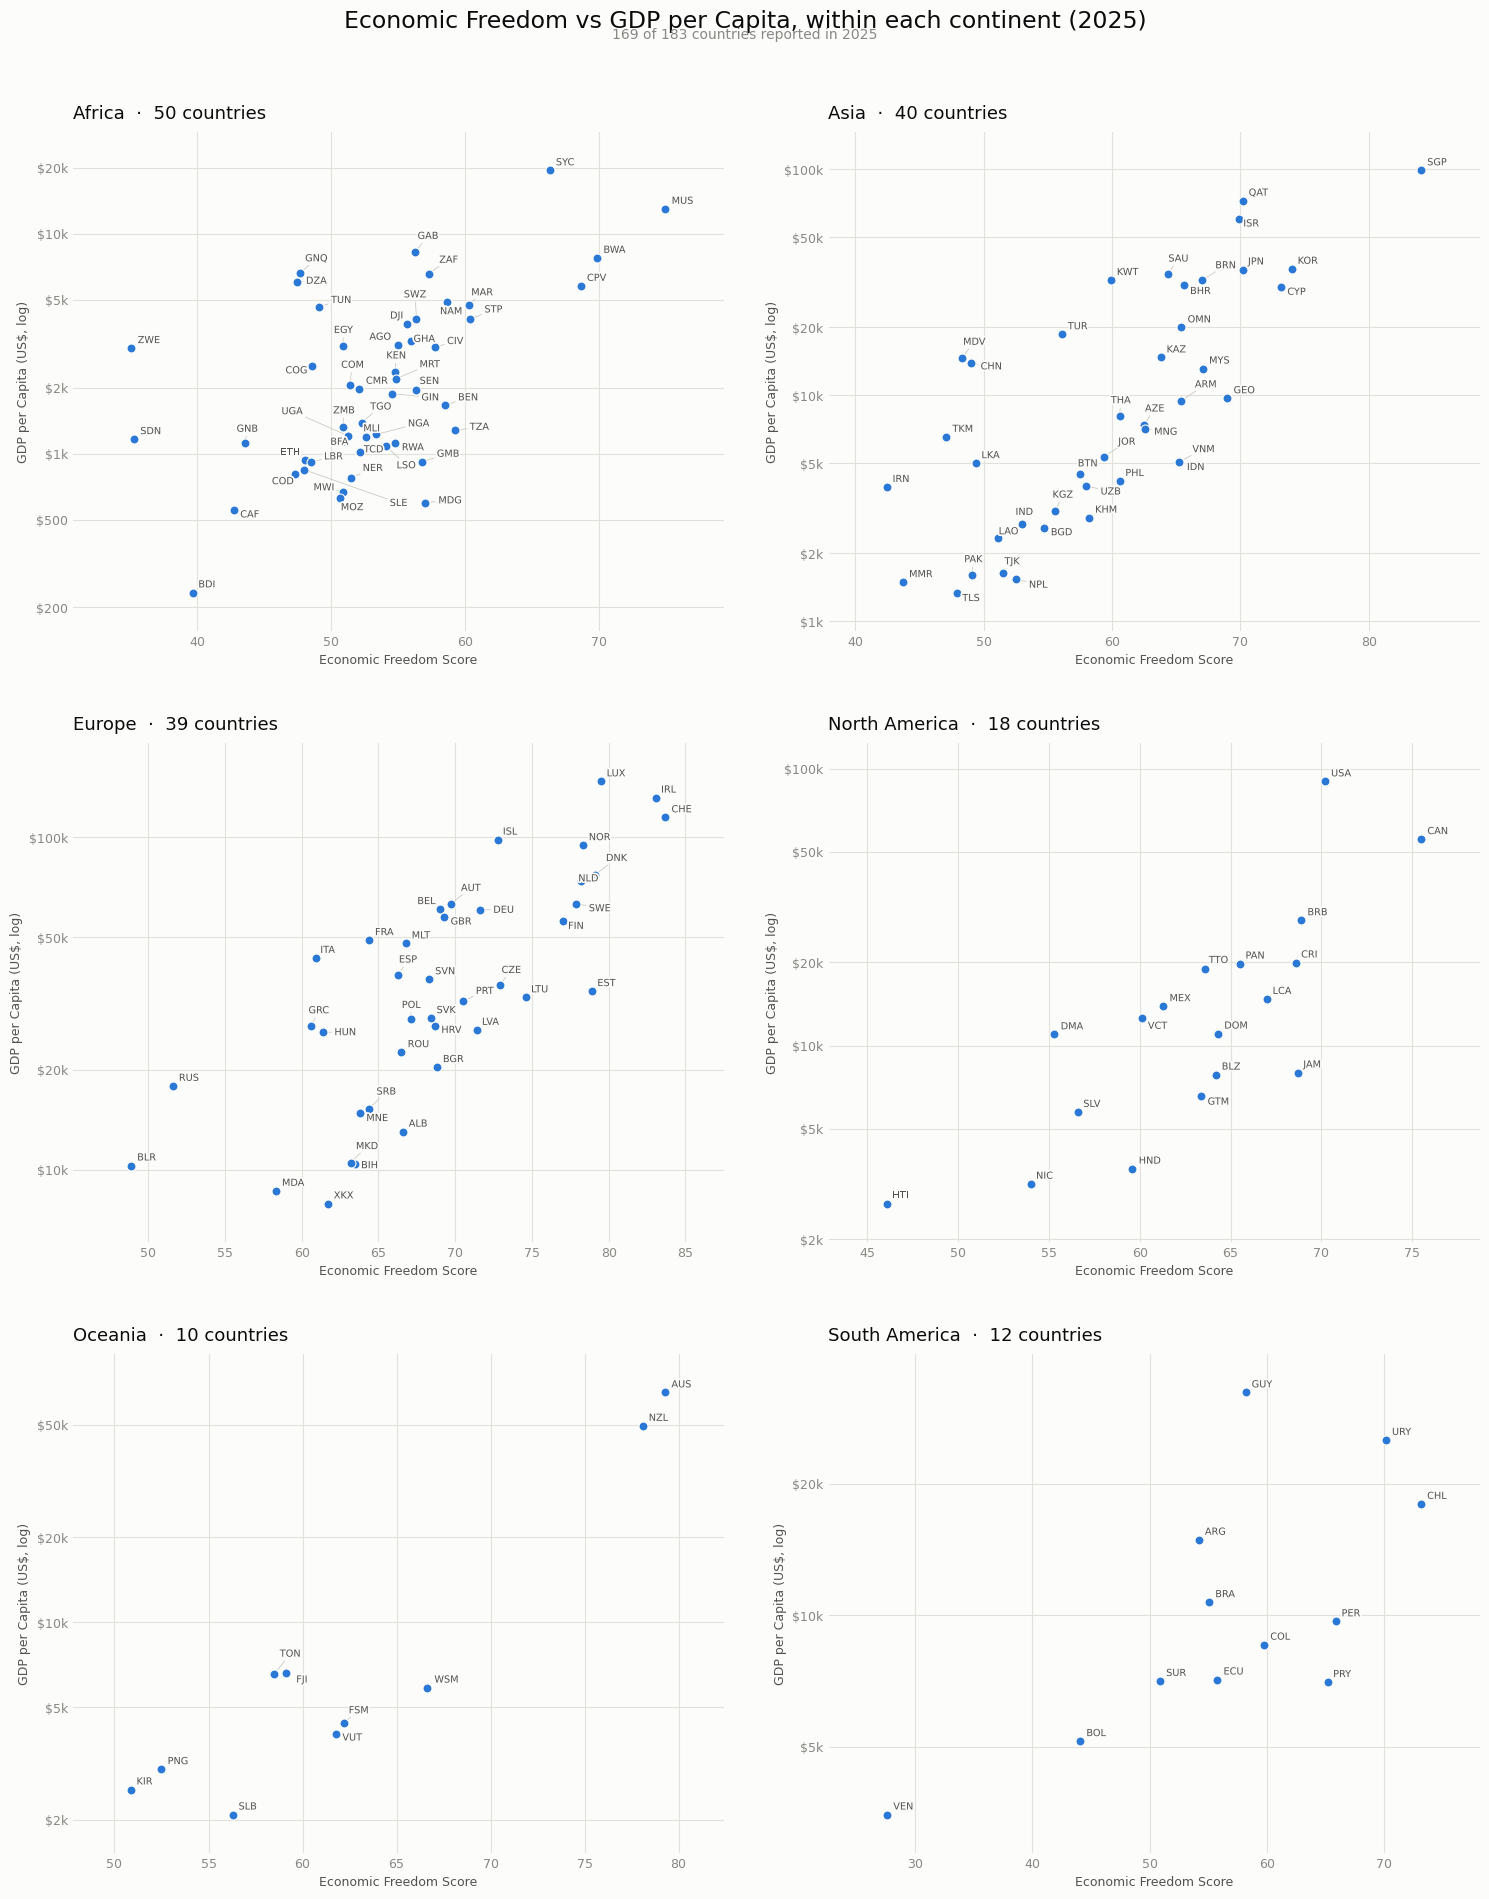

In [13]:
fig = viz.plot_continent_detail(
    snapshot,
    continents,
    latest_year,
    gdp_col,
    subtitle=utils.coverage_note(df, [freedom_col, gdp_col], latest_year),
)
plt.show()

## Part IV | Correlation Analysis Across Indicators

Quantify how strongly economic freedom sub-components correlate with development outcomes, to identify the strongest candidate relationships.

## Part V | Key Findings and Takeaways

Summarise the main patterns found in this notebook, to be carried into `III-ml.ipynb`.